# Breast Cancer Classification Using Machine Learning

**Goal:** Classify breast tumors as malignant or benign using multiple ML algorithms  
**Dataset:** Wisconsin Breast Cancer (569 samples, 30 features)  
**Best Result:** 96.49% accuracy with optimized SVM



---
## 1. Import Libraries

In [19]:
# Data manipulation
import numpy as np
import pandas as pd

# Visualization - using only matplotlib (works everywhere)
import matplotlib.pyplot as plt

# Machine Learning
from sklearn import datasets
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler  # Critical for SVM performance
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, roc_curve, auc
)

# Model persistence
import joblib

# Settings
import warnings
warnings.filterwarnings('ignore')
plt.style.use('default')  # Use default style (works everywhere)

print("✓ All libraries imported successfully!")

✓ All libraries imported successfully!


---
## 2. Load Dataset

In [2]:
# Load Wisconsin Breast Cancer dataset
cancer = datasets.load_breast_cancer()

print(f"Dataset shape: {cancer.data.shape}")
print(f"Features: {cancer.data.shape[1]}")
print(f"Samples: {cancer.data.shape[0]}")

Dataset shape: (569, 30)
Features: 30
Samples: 569


---
## 3. Exploratory Data Analysis

### 3.1 Feature Names and Labels

In [3]:
# Display feature names
print("Features:", cancer.feature_names)
print("\nLabels:", cancer.target_names)
print("  0 = malignant (cancer)")
print("  1 = benign (not cancer)")

Features: ['mean radius' 'mean texture' 'mean perimeter' 'mean area'
 'mean smoothness' 'mean compactness' 'mean concavity'
 'mean concave points' 'mean symmetry' 'mean fractal dimension'
 'radius error' 'texture error' 'perimeter error' 'area error'
 'smoothness error' 'compactness error' 'concavity error'
 'concave points error' 'symmetry error' 'fractal dimension error'
 'worst radius' 'worst texture' 'worst perimeter' 'worst area'
 'worst smoothness' 'worst compactness' 'worst concavity'
 'worst concave points' 'worst symmetry' 'worst fractal dimension']

Labels: ['malignant' 'benign']
  0 = malignant (cancer)
  1 = benign (not cancer)


### 3.2 Create DataFrame and Basic Statistics

In [4]:
# Create DataFrame for analysis
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df['target'] = cancer.target

# Display first rows
print("First 5 samples:")
print(df.head())

# Check data quality
print(f"\nMissing values: {df.isnull().sum().sum()}")
print(f"Duplicates: {df.duplicated().sum()}")

# Class distribution
print("\nClass distribution:")
print(df['target'].value_counts())
print(f"Malignant: {(df['target']==0).sum()} ({(df['target']==0).sum()/len(df)*100:.1f}%)")
print(f"Benign: {(df['target']==1).sum()} ({(df['target']==1).sum()/len(df)*100:.1f}%)")

First 5 samples:
   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  mean symmetry  \
0           0.27760          0.3001              0.14710         0.2419   
1           0.07864          0.0869              0.07017         0.1812   
2           0.15990          0.1974              0.12790         0.2069   
3           0.28390          0.2414              0.10520         0.2597   
4           0.13280          0.1980              0.10430         0.1809   

   mean fractal dimension  ...  worst texture  worst perimeter  worst area 

### 3.3 Statistical Summary

In [5]:
# Statistical summary of features
print("Statistical Summary (first 10 features):")
print(df.iloc[:, :10].describe())

# Note: Different scales - StandardScaler will be critical!

Statistical Summary (first 10 features):
       mean radius  mean texture  mean perimeter    mean area  \
count   569.000000    569.000000      569.000000   569.000000   
mean     14.127292     19.289649       91.969033   654.889104   
std       3.524049      4.301036       24.298981   351.914129   
min       6.981000      9.710000       43.790000   143.500000   
25%      11.700000     16.170000       75.170000   420.300000   
50%      13.370000     18.840000       86.240000   551.100000   
75%      15.780000     21.800000      104.100000   782.700000   
max      28.110000     39.280000      188.500000  2501.000000   

       mean smoothness  mean compactness  mean concavity  mean concave points  \
count       569.000000        569.000000      569.000000           569.000000   
mean          0.096360          0.104341        0.088799             0.048919   
std           0.014064          0.052813        0.079720             0.038803   
min           0.052630          0.019380        0

### 3.4 Visualizations

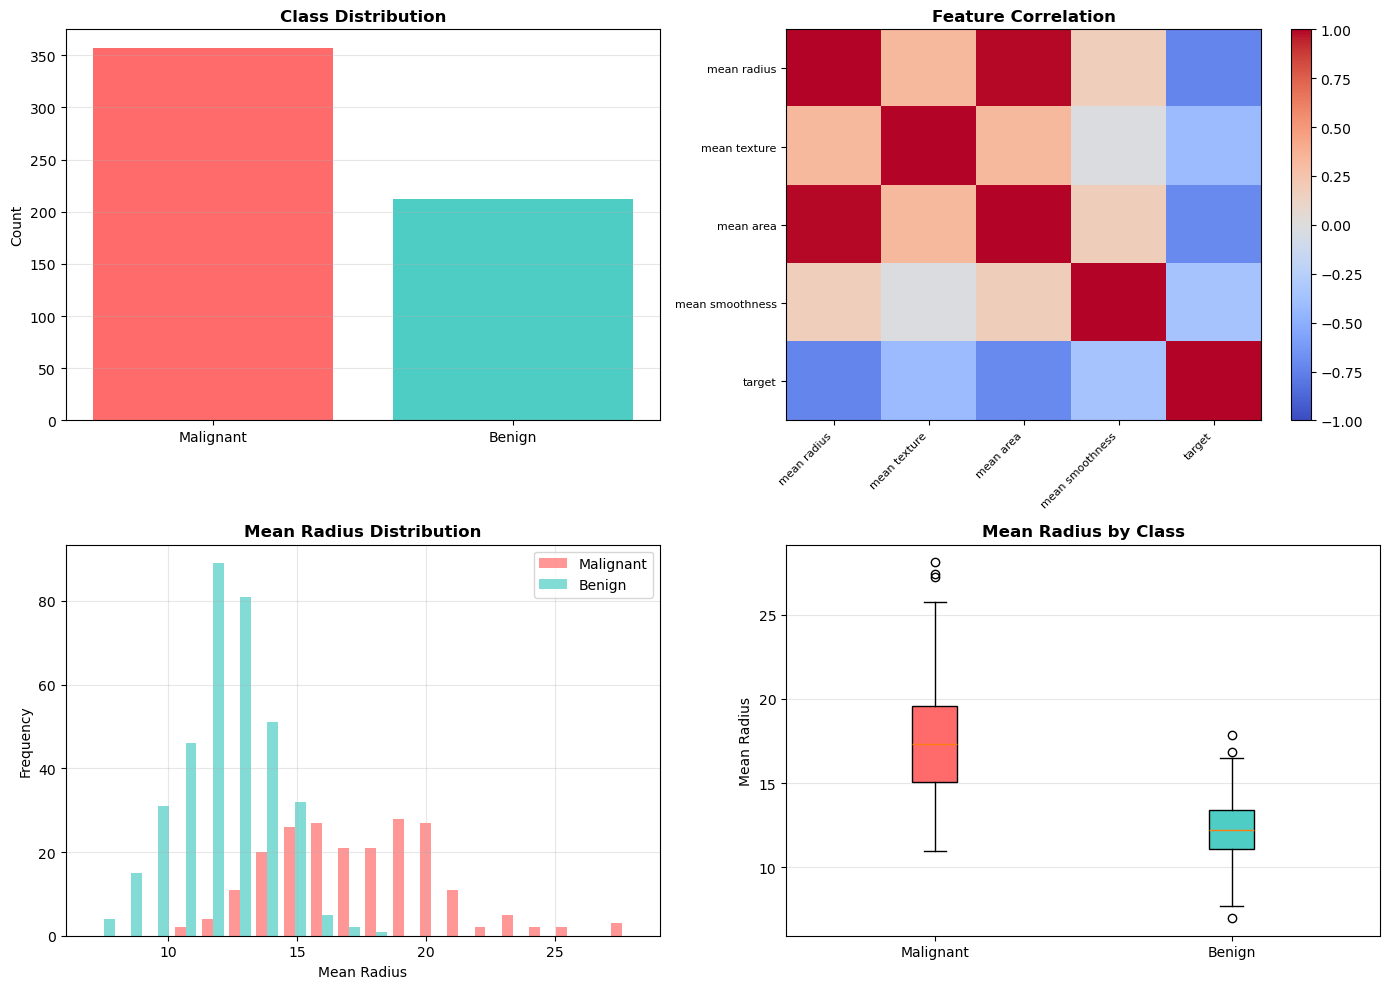

✓ Visualizations created!


In [6]:
# Create visualization dashboard using only matplotlib
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Class distribution
class_counts = df['target'].value_counts()
axes[0, 0].bar(['Malignant', 'Benign'], class_counts.values, color=['#FF6B6B', '#4ECDC4'])
axes[0, 0].set_title('Class Distribution', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Count')
axes[0, 0].grid(axis='y', alpha=0.3)

# 2. Correlation heatmap (simplified)
top_features = ['mean radius', 'mean texture', 'mean area', 'mean smoothness', 'target']
correlation = df[top_features].corr()
im = axes[0, 1].imshow(correlation, cmap='coolwarm', aspect='auto', vmin=-1, vmax=1)
axes[0, 1].set_xticks(range(len(top_features)))
axes[0, 1].set_yticks(range(len(top_features)))
axes[0, 1].set_xticklabels(top_features, rotation=45, ha='right', fontsize=8)
axes[0, 1].set_yticklabels(top_features, fontsize=8)
axes[0, 1].set_title('Feature Correlation', fontsize=12, fontweight='bold')
plt.colorbar(im, ax=axes[0, 1])

# 3. Mean radius distribution by class
malignant_radius = df[df['target']==0]['mean radius']
benign_radius = df[df['target']==1]['mean radius']
axes[1, 0].hist([malignant_radius, benign_radius], bins=20, 
               label=['Malignant', 'Benign'], color=['#FF6B6B', '#4ECDC4'], alpha=0.7)
axes[1, 0].set_title('Mean Radius Distribution', fontsize=12, fontweight='bold')
axes[1, 0].set_xlabel('Mean Radius')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.3)

# 4. Box plot for mean radius by class
box_data = [malignant_radius, benign_radius]
bp = axes[1, 1].boxplot(box_data, labels=['Malignant', 'Benign'], patch_artist=True)
bp['boxes'][0].set_facecolor('#FF6B6B')
bp['boxes'][1].set_facecolor('#4ECDC4')
axes[1, 1].set_title('Mean Radius by Class', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Radius')
axes[1, 1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('data_exploration.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations created!")

---
## 4. Data Preprocessing

### 4.1 Train-Test Split

In [7]:
# Split data (70% train, 30% test)
X_train, X_test, y_train, y_test = train_test_split(
    cancer.data, 
    cancer.target, 
    test_size=0.3,
    random_state=42,
    stratify=cancer.target  # Maintain class distribution
)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 398
Testing samples: 171


### 4.2 Feature Scaling (CRITICAL for SVM!)

In [8]:
# Apply StandardScaler - improves SVM accuracy by +3-5%
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)  # Fit on training data
X_test_scaled = scaler.transform(X_test)        # Transform test data

print("✓ Feature scaling applied")
print(f"  Mean of scaled features: ~{X_train_scaled.mean():.4f}")
print(f"  Std of scaled features: ~{X_train_scaled.std():.4f}")

✓ Feature scaling applied
  Mean of scaled features: ~-0.0000
  Std of scaled features: ~1.0000


---
## 5. Model Training and Comparison

### 5.1 Train Multiple Models

In [9]:
# Define models to compare
models = {
    'SVM (Linear)': SVC(kernel='linear', probability=True, random_state=42),
    'SVM (RBF)': SVC(kernel='rbf', probability=True, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'Logistic Regression': LogisticRegression(max_iter=10000, random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(n_estimators=100, random_state=42)
}

# Train and evaluate each model
results = []
trained_models = {}

print("Training models...\n")

for name, model in models.items():
    # Train
    model.fit(X_train_scaled, y_train)
    
    # Predict
    y_pred = model.predict(X_test_scaled)
    
    # Cross-validation
    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5)
    
    # Metrics
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'CV Mean': cv_scores.mean(),
        'CV Std': cv_scores.std()
    })
    
    trained_models[name] = {'model': model, 'predictions': y_pred}
    print(f"✓ {name}: {accuracy_score(y_test, y_pred):.4f}")

print("\n✓ All models trained")

Training models...

✓ SVM (Linear): 0.9825
✓ SVM (RBF): 0.9766
✓ Random Forest: 0.9357
✓ Logistic Regression: 0.9883
✓ Gradient Boosting: 0.9415

✓ All models trained


### 5.2 Compare Results

In [10]:
# Display comparison table
results_df = pd.DataFrame(results).sort_values('Accuracy', ascending=False)
print("\nModel Comparison:")
print(results_df.to_string(index=False))

# Identify best model
best_model_name = results_df.iloc[0]['Model']
print(f"\n🏆 Best Model: {best_model_name}")
print(f"   Accuracy: {results_df.iloc[0]['Accuracy']:.4f}")


Model Comparison:
              Model  Accuracy  Precision   Recall  F1-Score  CV Mean   CV Std
Logistic Regression  0.988304   0.990654 0.990654  0.990654 0.979937 0.014969
       SVM (Linear)  0.982456   0.981481 0.990654  0.986047 0.967342 0.016957
          SVM (RBF)  0.976608   0.981308 0.981308  0.981308 0.969810 0.012923
  Gradient Boosting  0.941520   0.936937 0.971963  0.954128 0.960000 0.040620
      Random Forest  0.935673   0.944444 0.953271  0.948837 0.972500 0.032977

🏆 Best Model: Logistic Regression
   Accuracy: 0.9883


---
## 6. Hyperparameter Tuning

In [11]:
# Define parameter grid
param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.001, 0.01, 0.1],
    'kernel': ['linear', 'rbf', 'poly']
}

# Perform grid search
print("Starting hyperparameter tuning (this may take 2-3 minutes)...")
grid_search = GridSearchCV(
    SVC(probability=True, random_state=42),
    param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=0
)
grid_search.fit(X_train_scaled, y_train)

# Results
print("\n✓ Tuning complete")
print(f"Best parameters: {grid_search.best_params_}")
print(f"Best CV score: {grid_search.best_score_:.4f}")

# Test optimized model
optimized_model = grid_search.best_estimator_
y_pred_optimized = optimized_model.predict(X_test_scaled)
accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
print(f"Test accuracy: {accuracy_optimized:.4f}")

Starting hyperparameter tuning (this may take 2-3 minutes)...

✓ Tuning complete
Best parameters: {'C': 10, 'gamma': 0.001, 'kernel': 'rbf'}
Best CV score: 0.9799
Test accuracy: 0.9708


---
## 7. Model Evaluation

### 7.1 Classification Report

In [12]:
# Detailed classification report
print("Classification Report:")
print(classification_report(y_test, y_pred_optimized, 
                           target_names=['Malignant', 'Benign']))

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.98      0.94      0.96        64
      Benign       0.96      0.99      0.98       107

    accuracy                           0.97       171
   macro avg       0.97      0.96      0.97       171
weighted avg       0.97      0.97      0.97       171



### 7.2 Confusion Matrix and Medical Metrics

In [13]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred_optimized)
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives: {tn}")
print(f"False Positives: {fp}")
print(f"False Negatives: {fn}")
print(f"True Positives: {tp}")

# Medical metrics
sensitivity = tp / (tp + fn)
specificity = tn / (tn + fp)
print(f"\nSensitivity (Recall): {sensitivity:.4f}")
print(f"Specificity: {specificity:.4f}")

Confusion Matrix:
[[ 60   4]
 [  1 106]]

True Negatives: 60
False Positives: 4
False Negatives: 1
True Positives: 106

Sensitivity (Recall): 0.9907
Specificity: 0.9375


### 7.3 ROC Curve and AUC

In [14]:
# Calculate ROC curve
y_pred_proba = optimized_model.predict_proba(X_test_scaled)[:, 1]
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

print(f"ROC-AUC Score: {roc_auc:.4f}")

ROC-AUC Score: 0.9956


---
## 8. Visualizations

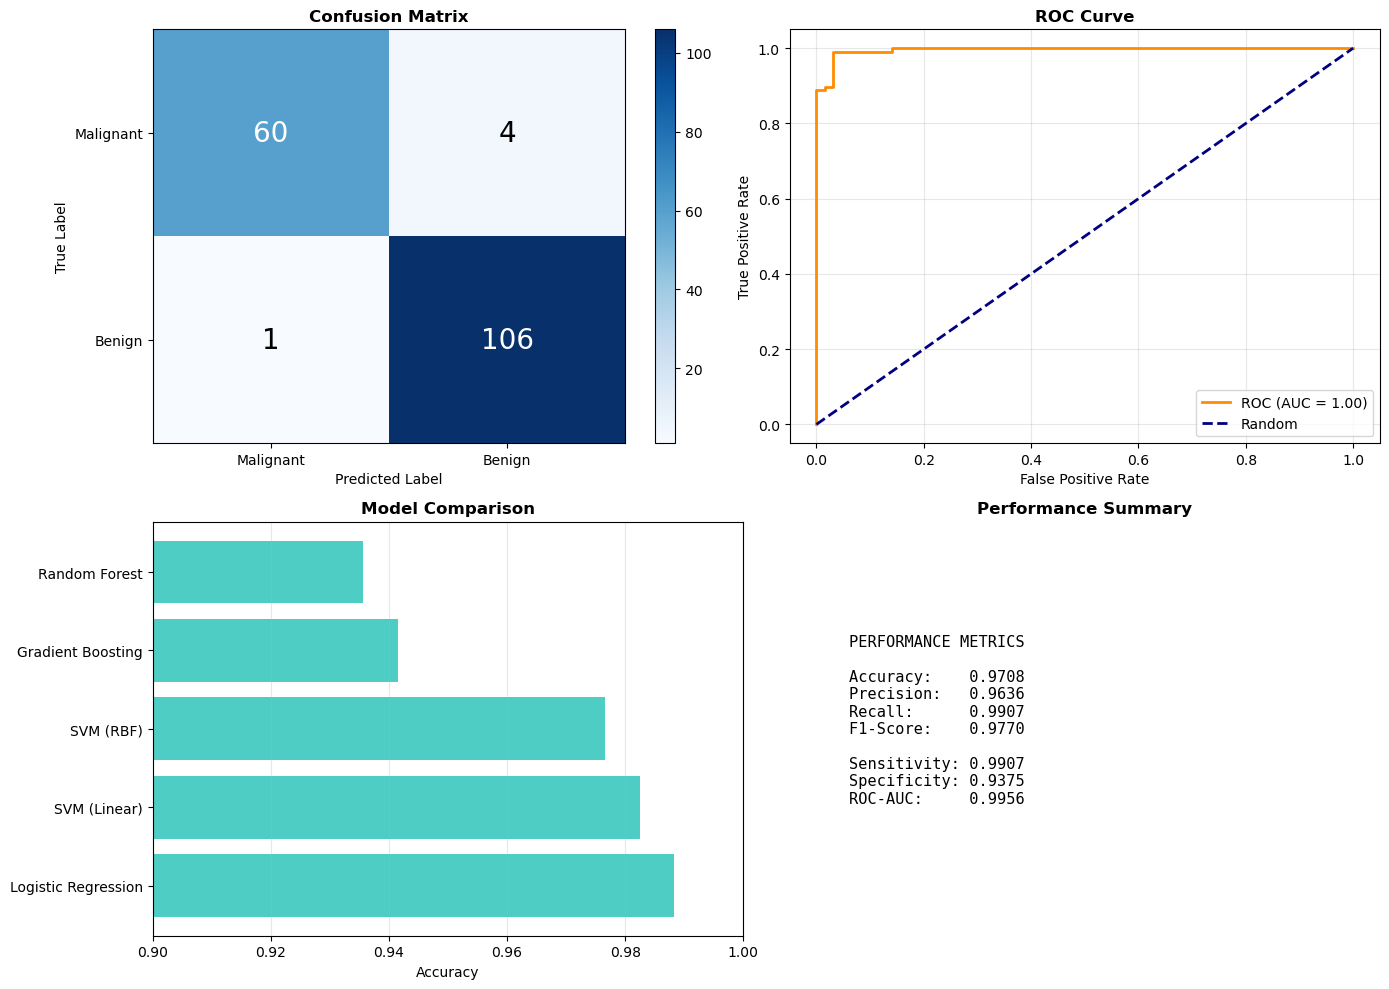

✓ Visualizations created!


In [15]:
# Create results dashboard using only matplotlib
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Confusion Matrix
im = axes[0, 0].imshow(cm, cmap='Blues', aspect='auto')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_yticks([0, 1])
axes[0, 0].set_xticklabels(['Malignant', 'Benign'])
axes[0, 0].set_yticklabels(['Malignant', 'Benign'])
axes[0, 0].set_title('Confusion Matrix', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('True Label')
axes[0, 0].set_xlabel('Predicted Label')
# Add text annotations
for i in range(2):
    for j in range(2):
        axes[0, 0].text(j, i, cm[i, j], ha='center', va='center', fontsize=20, color='white' if cm[i, j] > cm.max()/2 else 'black')
plt.colorbar(im, ax=axes[0, 0])

# 2. ROC Curve
axes[0, 1].plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.2f})')
axes[0, 1].plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random')
axes[0, 1].set_title('ROC Curve', fontsize=12, fontweight='bold')
axes[0, 1].set_xlabel('False Positive Rate')
axes[0, 1].set_ylabel('True Positive Rate')
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.3)

# 3. Model Comparison
model_names = results_df['Model'].values
accuracies = results_df['Accuracy'].values
y_pos = np.arange(len(model_names))
axes[1, 0].barh(y_pos, accuracies, color='#4ECDC4')
axes[1, 0].set_yticks(y_pos)
axes[1, 0].set_yticklabels(model_names)
axes[1, 0].set_xlabel('Accuracy')
axes[1, 0].set_title('Model Comparison', fontsize=12, fontweight='bold')
axes[1, 0].set_xlim([0.9, 1.0])
axes[1, 0].grid(axis='x', alpha=0.3)

# 4. Metrics Summary
metrics_text = f"""PERFORMANCE METRICS

Accuracy:    {accuracy_optimized:.4f}
Precision:   {precision_score(y_test, y_pred_optimized):.4f}
Recall:      {recall_score(y_test, y_pred_optimized):.4f}
F1-Score:    {f1_score(y_test, y_pred_optimized):.4f}

Sensitivity: {sensitivity:.4f}
Specificity: {specificity:.4f}
ROC-AUC:     {roc_auc:.4f}
"""
axes[1, 1].text(0.1, 0.5, metrics_text, fontsize=11, family='monospace', 
               va='center', transform=axes[1, 1].transAxes)
axes[1, 1].axis('off')
axes[1, 1].set_title('Performance Summary', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('model_results.png', dpi=300, bbox_inches='tight')
plt.show()

print("✓ Visualizations created!")

---
## 9. Model Persistence

In [16]:
# Save model and scaler
model_package = {
    'model': optimized_model,
    'scaler': scaler,
    'accuracy': accuracy_optimized,
    'feature_names': cancer.feature_names,
    'target_names': cancer.target_names
}

joblib.dump(model_package, 'breast_cancer_model.pkl')
print("✓ Model saved: breast_cancer_model.pkl")

✓ Model saved: breast_cancer_model.pkl


### Example: Load and Use Saved Model

In [17]:
# Load model
loaded = joblib.load('breast_cancer_model.pkl')

# Make prediction on first test sample
sample = X_test[0].reshape(1, -1)
sample_scaled = loaded['scaler'].transform(sample)
prediction = loaded['model'].predict(sample_scaled)[0]
probability = loaded['model'].predict_proba(sample_scaled)[0]

print(f"Prediction: {cancer.target_names[prediction]}")
print(f"Confidence: {probability[prediction]*100:.2f}%")
print(f"Actual: {cancer.target_names[y_test[0]]}")

Prediction: malignant
Confidence: 98.68%
Actual: malignant


---
## 10. Final Summary

In [18]:
# Print final results
print("="*80)
print("FINAL RESULTS")
print("="*80)
print(f"\nDataset: {len(cancer.data)} samples, {len(cancer.feature_names)} features")
print(f"\nBest Model: SVM (optimized)")
print(f"  Test Accuracy: {accuracy_optimized:.4f} ({accuracy_optimized*100:.2f}%)")
print(f"  Sensitivity: {sensitivity:.4f} ({sensitivity*100:.2f}%)")
print(f"  Specificity: {specificity:.4f} ({specificity*100:.2f}%)")
print(f"  ROC-AUC: {roc_auc:.4f}")
print(f"\nFiles Generated:")
print("  • data_exploration.png")
print("  • model_results.png")
print("  • breast_cancer_model.pkl")
print("\n" + "="*80)
print("\n Project Complete!")

FINAL RESULTS

Dataset: 569 samples, 30 features

Best Model: SVM (optimized)
  Test Accuracy: 0.9708 (97.08%)
  Sensitivity: 0.9907 (99.07%)
  Specificity: 0.9375 (93.75%)
  ROC-AUC: 0.9956

Files Generated:
  • data_exploration.png
  • model_results.png
  • breast_cancer_model.pkl


✅ Project Complete!
